# lists 

In [8]:
list_1  = [20, 35, 47, 88, 156, 204, 512, 777, 1043, 2048]
list_2  = [21, 44, 63, 90, 175, 300, 528, 810, 1100, 2222]
list_3  = [25, 50, 75, 100, 200, 333, 600, 900, 1250, 2500]
list_4  = [22, 48, 96, 144, 256, 400, 640, 880, 1500, 3000]
list_5  = [30, 60, 120, 180, 240, 480, 720, 960, 1800, 3600]
list_6  = [27, 54, 108, 216, 333, 432, 666, 999, 1333, 2666]
list_7  = [33, 66, 132, 264, 396, 528, 792, 1056, 1584, 3168]
list_8  = [40, 80, 160, 320, 500, 640, 800, 1200, 2000, 4000]
list_9  = [45, 90, 135, 270, 405, 540, 810, 1215, 2025, 4050]
list_10 = [50, 100, 150, 300, 450, 600, 900, 1350, 2250, 4500]

# ro df 

In [10]:
import pandas as pd

df = pd.DataFrame({
    "list_1": list_1, "list_2": list_2, "list_3": list_3, "list_4": list_4,
    "list_5": list_5, "list_6": list_6, "list_7": list_7, "list_8": list_8,
    "list_9": list_9, "list_10": list_10,
})

# or by name 

In [11]:
df = pd.DataFrame({f"list_{i}": globals()[f"list_{i}"] for i in range(1, 11)})

# convert df to lists 

In [13]:
i = 1
for col in df.columns:
    vars()[f"new_list_{i}"] = df[col].tolist()
    i = i + 1

# NOrmalize one list 

In [15]:
new_list_1

[20, 35, 47, 88, 156, 204, 512, 777, 1043, 2048]

In [16]:
new_list_1_norm = [(x - min(new_list_1)) / (max(new_list_1) - min(new_list_1)) for x in new_list_1] # x is each value
new_list_1_norm

[0.0,
 0.0073964497041420114,
 0.013313609467455622,
 0.03353057199211045,
 0.0670611439842209,
 0.09072978303747535,
 0.24260355029585798,
 0.3732741617357002,
 0.5044378698224852,
 1.0]

In [18]:
# Why is 0-1 : BECAUSE NORMAL DISTRIBUTION is  N(0,1) -> AKA (0-100%) ::: COMPUTERS LIKE PERCENTAGES ! 

# normalize all columns 

In [19]:
for col in df.columns:
    df[f"{col}_norm"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

In [20]:
df

,list_1,list_2,list_3,list_4,list_5,list_6,list_7,list_8,list_9,list_10,list_1_norm,list_2_norm,list_3_norm,list_4_norm,list_5_norm,list_6_norm,list_7_norm,list_8_norm,list_9_norm,list_10_norm
0,20,21,25,22,30,27,33,40,45,50,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,35,44,50,48,60,54,66,80,90,100,0.007396,0.010450,0.010101,0.008731,0.008403,0.010231,0.010526,0.010101,0.011236,0.011236
2,47,63,75,96,120,108,132,160,135,150,0.013314,0.019082,0.020202,0.024849,0.025210,0.030693,0.031579,0.030303,0.022472,0.022472
3,88,90,100,144,180,216,264,320,270,300,0.033531,0.031349,0.030303,0.040967,0.042017,0.071618,0.073684,0.070707,0.056180,0.056180
4,156,175,200,256,240,333,396,500,405,450,0.067061,0.069968,0.070707,0.078576,0.058824,0.115953,0.115789,0.116162,0.089888,0.089888
5,204,300,333,400,480,432,528,640,540,600,0.090730,0.126761,0.124444,0.126931,0.126050,0.153467,0.157895,0.151515,0.123596,0.123596
6,512,528,600,640,720,666,792,800,810,900,0.242604,0.230350,0.232323,0.207522,0.193277,0.242137,0.242105,0.191919,0.191011,0.191011
7,777,810,900,880,960,999,1056,1200,1215,1350,0.373274,0.358473,0.353535,0.288113,0.260504,0.368321,0.326316,0.292929,0.292135,0.292135
8,1043,1100,1250,1500,1800,1333,1584,2000,2025,2250,0.504438,0.490232,0.494949,0.496306,0.495798,0.494884,0.494737,0.494949,0.494382,0.494382
9,2048,2222,2500,3000,3600,2666,3168,4000,4050,4500,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# how many ways to mnormalize ?

* Min-Max → scales to [0, 1]. (x - min) / (max - min) *******
* Min-Max custom range → [a, b]. a + (x-min)(b-a)/(max-min)
* Z-score (standardization) → mean 0, std 1. (x - μ) / σ
* Max-abs → [-1, 1], preserves sign/sparsity. x / max(|x|)
* Robust → uses median + IQR, outlier-resistant. (x - median) / IQR
* L1 norm → divide by sum of abs values. x / Σ|x|
* L2 / unit vector → divide by Euclidean norm. x / ‖x‖₂
* Decimal scaling → shift decimal by power of 10. x / 10ⁱ
* Log transform → compress skew. log(x) or log(1+x)
* Mean normalization → centered, scaled by range. (x - μ) / (max - min)
* Quantile / rank → maps to uniform or normal dist (sklearn QuantileTransformer)
* Power transforms → Box-Cox, Yeo-Johnson — fix skew, stabilize variance

saved -> normalization_slide.png   before=Ben  after=Anna


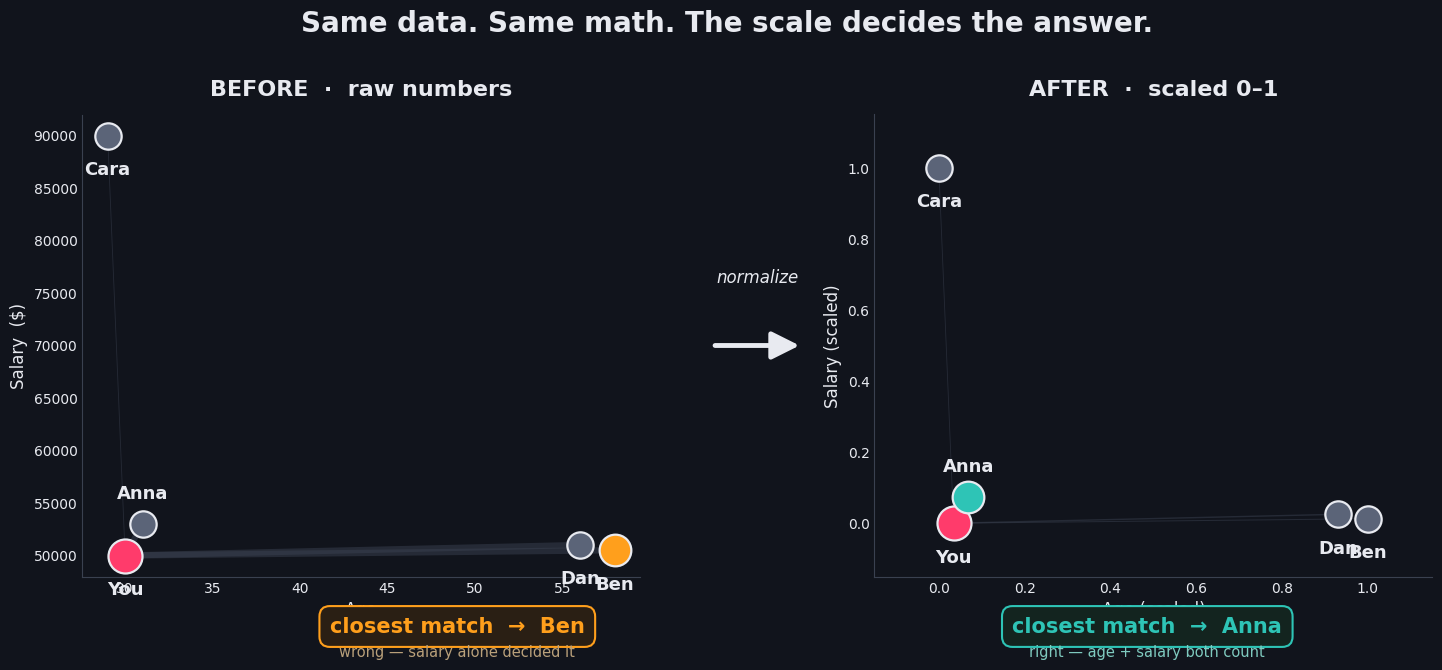

In [25]:
"""
Normalization — ONE slide, age vs salary, designed to actually look good.

Layout (single row, reads like a sentence):
   [ BEFORE scatter ]   -->   [ AFTER scatter ]
   verdict: Ben (wrong)        verdict: Anna (right)

Same data as before, but the visual is the point now: dark theme,
big result banners, a giant arrow, minimal chart junk.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ---- data -------------------------------------------------------------
names  = np.array(["You", "Anna", "Ben", "Cara", "Dan"])
age    = np.array([30, 31, 58, 29, 56])
salary = np.array([50000, 53000, 50500, 90000, 51000])
you = 0

mm = lambda x: (x - x.min()) / (x.max() - x.min())
raw  = np.column_stack([age, salary])
norm = np.column_stack([mm(age), mm(salary)])
dist = lambda d: np.sqrt(((d - d[you]) ** 2).sum(1))
win  = lambda d: names[np.argsort(dist(d))[1]]
before, after = win(raw), win(norm)

# ---- style ------------------------------------------------------------
BG, FG = "#11141c", "#e8eaf0"
YOU_C, WRONG_C, RIGHT_C, DIM = "#ff3b6b", "#ff9f1c", "#2ec4b6", "#3a4150"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "text.color": FG, "axes.labelcolor": FG,
    "xtick.color": FG, "ytick.color": FG, "axes.edgecolor": DIM,
    "font.family": "DejaVu Sans",
})

fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 2, wspace=0.42, left=0.07, right=0.97, top=0.78, bottom=0.12)

def panel(ax, pts, verdict, correct, header, sub):
    # connector lines from You to everyone (thicker = closer)
    d = dist(pts)
    dmax = d[1:].max()
    for i in range(len(names)):
        if i == you:
            continue
        close = 1 - d[i] / dmax
        ax.plot([pts[you, 0], pts[i, 0]], [pts[you, 1], pts[i, 1]],
                color=DIM, lw=0.6 + 4 * close, alpha=0.5, zorder=1)
    # dots
    for i, n in enumerate(names):
        if i == you:
            c, s = YOU_C, 600
        elif n == verdict:
            c, s = (RIGHT_C if correct else WRONG_C), 520
        else:
            c, s = "#5b6478", 360
        ax.scatter(*pts[i], s=s, c=c, edgecolor=FG, linewidth=1.6, zorder=3)
        # nudge labels apart: You below, Anna above (they sit close together)
        dy = 18 if n == "Anna" else -28
        ax.annotate(n, pts[i], textcoords="offset points", xytext=(0, dy),
                    ha="center", fontsize=13, fontweight="bold", color=FG, zorder=4)
    ax.set_title(header, fontsize=16, fontweight="bold", pad=14, color=FG)
    ax.set_xlabel(sub[0], fontsize=12); ax.set_ylabel(sub[1], fontsize=12)
    ax.tick_params(length=0)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

axL = fig.add_subplot(gs[0, 0])
panel(axL, raw, before, False,
      "BEFORE  ·  raw numbers",
      ("Age", "Salary  ($)"))

axR = fig.add_subplot(gs[0, 1])
panel(axR, norm, after, True,
      "AFTER  ·  scaled 0–1",
      ("Age (scaled)", "Salary (scaled)"))
axR.set_xlim(-0.15, 1.15); axR.set_ylim(-0.15, 1.15)

# ---- verdict banners under each panel --------------------------------
fig.text(0.32, 0.04, f"closest match  →  {before}", ha="center", fontsize=15,
         fontweight="bold", color=WRONG_C,
         bbox=dict(boxstyle="round,pad=0.5", fc="#2a1f14", ec=WRONG_C, lw=1.5))
fig.text(0.32, 0.005, "wrong — salary alone decided it", ha="center",
         fontsize=10.5, color="#b9a07a")

fig.text(0.78, 0.04, f"closest match  →  {after}", ha="center", fontsize=15,
         fontweight="bold", color=RIGHT_C,
         bbox=dict(boxstyle="round,pad=0.5", fc="#13241f", ec=RIGHT_C, lw=1.5))
fig.text(0.78, 0.005, "right — age + salary both count", ha="center",
         fontsize=10.5, color="#7fcabf")

# ---- big arrow between panels ----------------------------------------
arr = FancyArrowPatch((0.49, 0.45), (0.55, 0.45), transform=fig.transFigure,
                      arrowstyle="-|>", mutation_scale=42, lw=3.5,
                      color=FG, zorder=10)
fig.add_artist(arr)
fig.text(0.52, 0.54, "normalize", ha="center", fontsize=12,
         style="italic", color=FG)

fig.suptitle("Same data. Same math. The scale decides the answer.",
             fontsize=20, fontweight="bold", color=FG, y=0.93)

out = "normalization_slide.png"
fig.savefig(out, dpi=140, facecolor=BG)
print(f"saved -> {out}   before={before}  after={after}")